# Biomechanical parameters — video vs. Optojump

Computes ground contact time, flight time, and step length from pose-based gait phase
predictions, then compares them to Optojump ground-truth measurements.

**Optojump filter:** only steps after the 20 m mark (`distance > 2000 cm`) are used
to avoid acceleration-phase artefacts.

**Predictions source:** TCN inference manifest (`stage6`).  Falls back to ground-truth
labels from the annotation CSV if the manifest is absent.

In [6]:
import json
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import ndarray

from experiments.gait_detection.config import ExperimentConfig
from src.gait.detection.detectors import KinematicDetector, XGBoostDetector
from src.gait.detection.postprocess import (
    estimate_hmm_params,
    viterbi_decode,
)
from src.gait.gait_data.dataset import load_dataset_with_pose, train_test_split, VideoRecord
from src.gait.parameters.biomechanics import (
    gait_intervals,
    compute_cadence,
    compute_step_lengths,
    compute_joint_angles,
)


In [7]:
# Label source: "tcn" | "img_tcn" | "resnet" | "xgb" | "img_xgb" | "kinematic" | "annotations"
LABEL_SOURCE = "tcn"

# paths
TCN_MANIFEST          = "data/output/gait/pose_data/stage6/manifest.json"
IMG_TCN_MANIFEST      = "data/output/gait/image/stage6/manifest.json"
RESNET_MANIFEST       = "data/output/gait/image/resnet/infer/manifest.json"
XGB_LOAO_MANIFEST     = "data/output/gait/pose_data/xgb_loao/manifest.json"
IMG_XGB_LOAO_MANIFEST = "data/output/gait/image/xgb_loao/manifest.json"
IMG_XGB_MODEL_PATH    = "data/output/gait/image/stage1/checkpoints/xgboost_best.pkl"  # fallback

OPTOJUMP_CSV    = "data/input/optojump/optojump_output/parsed/optojump_basic.csv"
RUNNER_HEIGHT_M = 2.0
POSTPROCESS_WIN = 3    # window for soft-label smoothing
MIN_DISTANCE_CM = 2000


In [8]:
os.chdir('..')

## Load pose data + predictions

In [9]:
_manifest_idx: dict | None = None
_xgb_detector: XGBoostDetector | None = None

def _load_infer_manifest(path, label):
    """Load an inference manifest and update _manifest_idx for split lookup."""
    global _manifest_idx
    with open(path) as f:
        manifest = json.load(f)
    idx = {r["video_path"]: r for r in manifest["records"]}
    print(f"{label} manifest loaded — {len(idx)} records")
    _manifest_idx = idx
    return idx

def load_tcn_manifest():
    global _manifest_idx
    try:
        return _load_infer_manifest(TCN_MANIFEST, "TCN")
    except FileNotFoundError:
        if LABEL_SOURCE == "tcn":
            raise
        _manifest_idx = {}
        return {}

def load_img_tcn_manifest():
    return _load_infer_manifest(IMG_TCN_MANIFEST, "Image TCN")

def load_resnet_manifest():
    return _load_infer_manifest(RESNET_MANIFEST, "ResNet")

def _load_loao_manifest(path, label):
    """Load a LOAO (train-only) manifest and update _manifest_idx."""
    global _manifest_idx
    with open(path) as f:
        m = json.load(f)
    idx = {r["video_path"]: r for r in m["records"]}
    print(f"{label} LOAO manifest loaded — {len(idx)} records")
    _manifest_idx = idx
    return idx

def load_xgb_loao_manifest():
    return _load_loao_manifest(XGB_LOAO_MANIFEST, "XGBoost (pose)")

def load_img_xgb_loao_manifest():
    return _load_loao_manifest(IMG_XGB_LOAO_MANIFEST, "XGBoost (image)")


In [10]:
cfg = ExperimentConfig()
cfg.annotations_csv = "data/output/annotations/optojump/visibility_annotations.csv"

pairs = load_dataset_with_pose(cfg.annotations_csv, fps=cfg.fps)
all_records = [rec for rec, _ in pairs]
train_records, _, _ = train_test_split(all_records)

startprob, transmat = estimate_hmm_params([r.labels for r in train_records])
HMM_PARAMS = {"transmat": transmat, "startprob": startprob}
print(f"HMM params estimated from {len(train_records)} training records ({len(all_records)} total)")

HMM params estimated from 160 training records (176 total)


## Compute per-video biomechanical parameters

In [11]:
def _probs_from_manifest(manifest_idx, rec, T):
    """Load probs from a manifest entry, aligning length to T.
    Returns None if the record is not in the manifest.
    """
    entry = manifest_idx.get(rec.video_path)
    if entry is None:
        return None
    probs = np.load(entry["probs_path"])
    if len(probs) != T:
        probs = probs[:T] if len(probs) > T else np.pad(probs, ((0, T - len(probs)), (0, 0)), "edge")
    return probs


def _apply_postprocess(probs):
    return viterbi_decode(probs, **HMM_PARAMS)


_tcn_manifest_idx: dict | None = None

def load_labels_tcn(rec: VideoRecord) -> ndarray | None:
    global _tcn_manifest_idx
    if _tcn_manifest_idx is None:
        _tcn_manifest_idx = load_tcn_manifest()
    probs = _probs_from_manifest(_tcn_manifest_idx, rec, len(rec.labels))
    return None if probs is None else _apply_postprocess(probs)


_img_tcn_manifest_idx: dict | None = None

def load_labels_img_tcn(rec: VideoRecord) -> ndarray | None:
    global _img_tcn_manifest_idx
    if _img_tcn_manifest_idx is None:
        _img_tcn_manifest_idx = load_img_tcn_manifest()
    probs = _probs_from_manifest(_img_tcn_manifest_idx, rec, len(rec.labels))
    return None if probs is None else _apply_postprocess(probs)


_resnet_manifest_idx: dict | None = None

def load_labels_resnet(rec: VideoRecord) -> ndarray | None:
    global _resnet_manifest_idx
    if _resnet_manifest_idx is None:
        _resnet_manifest_idx = load_resnet_manifest()
    probs = _probs_from_manifest(_resnet_manifest_idx, rec, len(rec.labels))
    return None if probs is None else _apply_postprocess(probs)


_xgb_loao_idx: dict | None = None

def load_labels_xgb(rec: VideoRecord) -> ndarray | None:
    global _xgb_loao_idx
    if _xgb_loao_idx is None:
        _xgb_loao_idx = load_xgb_loao_manifest()
    probs = _probs_from_manifest(_xgb_loao_idx, rec, len(rec.labels))
    return None if probs is None else _apply_postprocess(probs)


_img_xgb_loao_idx: dict | None = None

def load_labels_img_xgb(rec: VideoRecord) -> ndarray | None:
    global _img_xgb_loao_idx
    if _img_xgb_loao_idx is None:
        _img_xgb_loao_idx = load_img_xgb_loao_manifest()
    probs = _probs_from_manifest(_img_xgb_loao_idx, rec, len(rec.labels))
    return None if probs is None else _apply_postprocess(probs)


def load_labels_kinematic(rec: VideoRecord) -> ndarray:
    return KinematicDetector().predict(rec.features, cfg.fps)


def load_labels_annotations(rec: VideoRecord) -> ndarray:
    return rec.labels


In [12]:
def _study_test(video_path: str) -> tuple[int, int]:
    path = Path(video_path)
    study_match = re.search(r"study_(\d+)", video_path)
    study_id = int(study_match.group(1)) if study_match else 0
    try:
        test_id = int(path.stem.split("_")[-1])
    except (ValueError, IndexError):
        test_id = 0
    return study_id, test_id

In [13]:
def make_bio_df(load_labels: callable) -> tuple[pd.DataFrame, dict]:
    results = []
    all_steps = {"contact": [], "flight": [], "length": []}
    n_skipped = 0

    for rec, pose_df in pairs:
        labels = load_labels(rec)
        if labels is None:
            n_skipped += 1
            continue

        study_id, test_id = _study_test(rec.video_path)
        meta = {"athlete": rec.athlete, "study_id": study_id, "test_id": test_id}

        ivs = gait_intervals(labels, fps=cfg.fps)
        cad = compute_cadence(labels, fps=cfg.fps)
        sl_df = compute_step_lengths(labels, pose_df, fps=cfg.fps, runner_height_m=RUNNER_HEIGHT_M)

        contact_segs = ivs["contact"][1:-1]
        flight_segs  = ivs["flight"][1:-1]
        sl_trimmed   = sl_df.iloc[1:-1]

        for key, source, col in [
            ("contact", contact_segs, "duration_s"),
            ("flight",  flight_segs,  "duration_s"),
        ]:
            step_df = pd.DataFrame(source).rename(columns={col: f"{key}_s"})
            all_steps[key].append(step_df.assign(**meta))

        if "step_length_m" in sl_trimmed.columns:
            sl_rows = sl_trimmed[["step_length_m"]].dropna()
        else:
            sl_rows = pd.DataFrame(columns=["step_length_m"])
        all_steps["length"].append(sl_rows.assign(**meta))

        gcts = [c["duration_s"] for c in contact_segs]
        flts = [f["duration_s"] for f in flight_segs]
        sls  = sl_trimmed["step_length_m"].dropna() if "step_length_m" in sl_trimmed.columns else pd.Series([], dtype=float)

        results.append({
            **meta,
            "video_path": rec.video_path,
            "mean_gct_s": np.nanmean(gcts) if gcts else np.nan,
            "mean_flight_s": np.nanmean(flts) if flts else np.nan,
            "mean_step_length_m": np.nanmean(sls) if not sls.empty else np.nan,
            "cadence_spm": cad["steps_per_minute"],
            "n_steps": cad["n_steps"],
        })

    if n_skipped:
        print(f"Skipped {n_skipped} records with no manifest entry (test-set records not in LOAO manifest).")
    return pd.DataFrame(results), all_steps


In [14]:
_loaders = {
    "tcn":         load_labels_tcn,
    "img_tcn":     load_labels_img_tcn,
    "resnet":      load_labels_resnet,
    "xgb":         load_labels_xgb,
    "img_xgb":     load_labels_img_xgb,
    "kinematic":   load_labels_kinematic,
    "annotations": load_labels_annotations,
}
if LABEL_SOURCE not in _loaders:
    raise ValueError(f"Unknown LABEL_SOURCE={LABEL_SOURCE!r}. Choose from: {list(_loaders)}")

print(f"Computing biomechanics — label source: {LABEL_SOURCE!r}")
bio_df, all_steps = make_bio_df(_loaders[LABEL_SOURCE])
contact_all  = pd.concat(all_steps["contact"], ignore_index=True)
flight_all   = pd.concat(all_steps["flight"],  ignore_index=True)
step_len_all = pd.concat(all_steps["length"],  ignore_index=True)


Computing biomechanics — label source: 'tcn'
TCN manifest loaded — 178 records


/var/folders/4x/6m7kwn5s2_78vxr_2xdtnlfw0000gn/T/ipykernel_59310/2551723991.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  step_len_all = pd.concat(all_steps["length"],  ignore_index=True)


## Load and filter Optojump data

In [15]:
oj = pd.read_csv(OPTOJUMP_CSV)

# Keep only steps after the 20 m mark
oj_post20 = oj[oj["distance"] > MIN_DISTANCE_CM].copy()

# "Marcin Jung" → "marcin_jung"
oj_post20["athlete"] = (
    oj_post20["full_name"].str.lower().str.replace(" ", "_", regex=False)
)

oj_post20["step_length_m"] = oj_post20["steps"] / 100.0
oj_post20["step_duration_s"]  = oj_post20["contact_time"] + oj_post20["flight_time"]

oj_agg = oj_post20.groupby(["athlete", "study_id", "test_id"], as_index=False).agg(
    mean_gct_s=("contact_time", "mean"),
    std_gct_s=("contact_time", "std"),
    mean_flight_s=("flight_time", "mean"),
    std_flight_s=("flight_time", "std"),
    mean_step_length_m=("step_length_m", "mean"),
    std_step_length_m=("step_length_m", "std"),
    n_steps=("contact_time", "count"),
    _total_dur=("step_duration_s", "sum"),
    _n=("step_duration_s", "count"),
)
oj_agg["cadence_spm"] = oj_agg["_n"] / oj_agg["_total_dur"] * 60
oj_agg = oj_agg.drop(columns=["_total_dur", "_n"])

## Merge video predictions with Optojump

In [16]:
merged = bio_df.merge(
    oj_agg,
    on=["athlete", "study_id", "test_id"],
    how="inner",
    suffixes=(None, "_oj"),
)  # video predictions + optojump

In [17]:
# Assign train/test split from manifest and report counts
merged["split"] = merged["video_path"].map(
    lambda vp: (_manifest_idx or {}).get(vp, {}).get("split", "unknown")
)
n_train = (merged["split"] == "train").sum()
n_test  = (merged["split"] == "test").sum()
print(f"Matched: {len(merged)} total  —  train: {n_train},  test: {n_test}")


Matched: 117 total  —  train: 106,  test: 11


# Error analysis


In [18]:
METRICS = [
    ("mean_gct_s",         "mean_gct_s",      "GCT (s)",         "#4e79a7"),
    ("mean_flight_s",      "mean_flight_s",   "Flight time (s)", "#59a14f"),
    ("mean_step_length_m", "mean_step_len_m", "Step length (m)", "#f28e2b"),
    ("cadence_spm",        "cadence_spm",     "Cadence (spm)",   "#e15759"),
]
SPLITS = ["train", "test"]

## Per-athlete error analysis

Heatmap shows NRMSE (%) per athlete and metric (pooled across splits).
Tables list the 5 worst-performing athletes per metric for the training split (the test split only contains two).

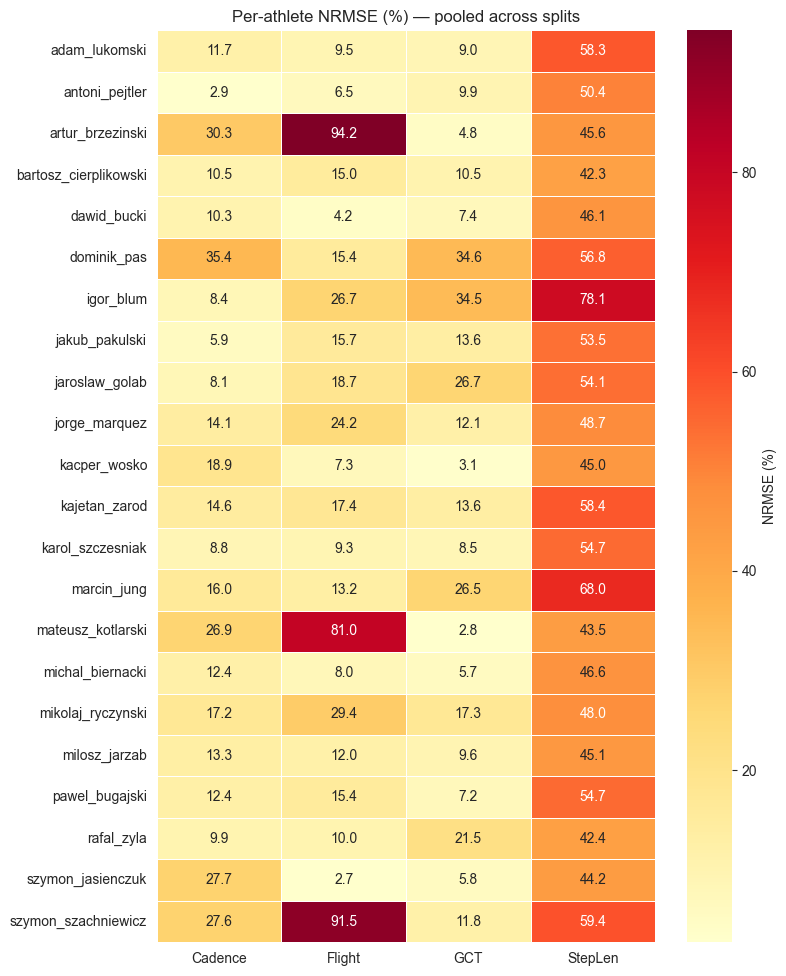

In [19]:
import seaborn as sns

_metric_defs = [
    ("mean_gct_s",         "mean_gct_s",      "GCT"),
    ("mean_flight_s",      "mean_flight_s",   "Flight"),
    ("mean_step_length_m", "mean_step_len_m", "StepLen"),
    ("cadence_spm",        "cadence_spm",     "Cadence"),
]

rows = []
for (athlete, split), g in merged.groupby(["athlete", "split"]):
    for video_col, optojump_col, label in _metric_defs:
        diff  = g[video_col] - g[f'{video_col}_oj']
        rmse  = np.sqrt((diff**2).mean())
        bias  = diff.mean()
        nrmse = rmse / g[f'{video_col}_oj'].mean() * 100
        rows.append({"athlete": athlete, "split": split, "metric": label,
                     "n": len(g), "bias": bias, "RMSE": rmse, "NRMSE (%)": nrmse})

ath_err = pd.DataFrame(rows)

hm = ath_err.pivot_table(index="athlete", columns="metric",
                          values="NRMSE (%)", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, max(5, len(hm) * 0.38 + 1.5)))
sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.4, cbar_kws={"label": "NRMSE (%)"})
ax.set_title("Per-athlete NRMSE (%) — pooled across splits")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [20]:
TOP_N = 5
for metric_label in ["GCT", "Flight", "StepLen"]:
    print(f"\n── {metric_label}: {TOP_N} highest-error athletes ──")
    sub = ath_err[ath_err["metric"] == metric_label]
    for split in ['train']:
        worst = (sub[sub["split"] == split]
                 .nlargest(TOP_N, "NRMSE (%)")
                 [["athlete", "n", "bias", "RMSE", "NRMSE (%)"]])
        if worst.empty:
            continue
        print(f"  {split}:")
        print(worst.round(4).to_string(index=False, col_space=18))


── GCT: 5 highest-error athletes ──
  train:
           athlete                  n               bias               RMSE          NRMSE (%)
       dominik_pas                  6            -0.0321             0.0485            34.6190
         igor_blum                  4            -0.0141             0.0486            34.4600
    jaroslaw_golab                  4            -0.0282             0.0425            26.6585
       marcin_jung                  6            -0.0160             0.0420            26.4553
        rafal_zyla                  5             0.0091             0.0301            21.4932

── Flight: 5 highest-error athletes ──
  train:
            athlete                  n               bias               RMSE          NRMSE (%)
   artur_brzezinski                  6            -0.0642             0.1592            94.2356
szymon_szachniewicz                  6            -0.0443             0.1293            91.4826
  mateusz_kotlarski                  6         

## Per-test-id error analysis

Heatmap shows NRMSE (%) per test_id and metric (train / test / all splits).
Bar chart compares Video vs. Optojump mean per test_id (pooled across athletes and studies).
Errors are sorted by NRMSE for each metric.

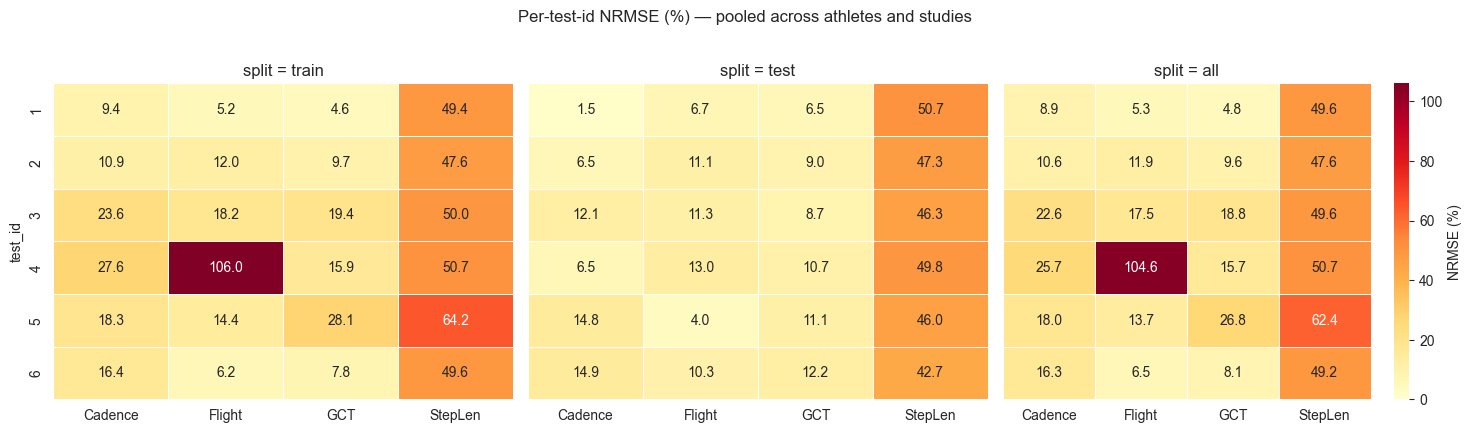

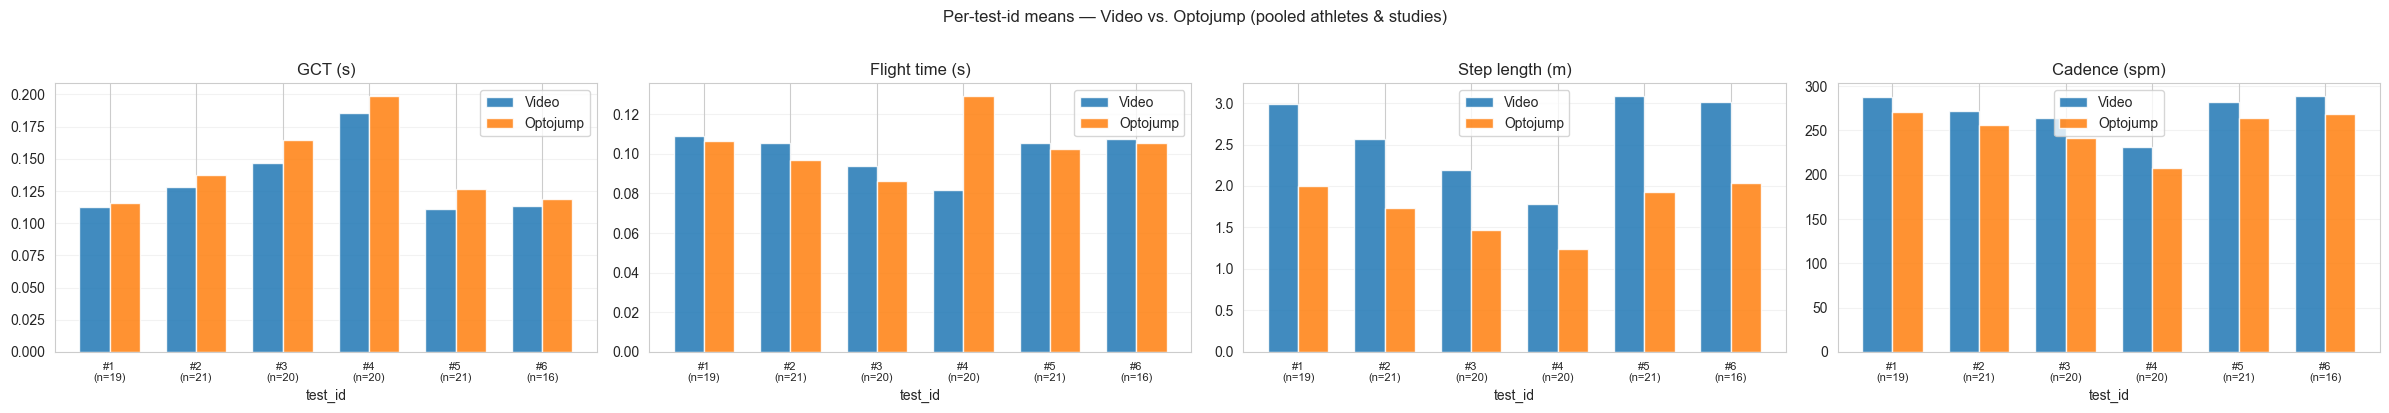

In [21]:
tid_rows = []
for (test_id, split), g in merged.groupby(["test_id", "split"]):
    for video_col, optojump_col, label in _metric_defs:
        diff = g[video_col] - g[f'{video_col}_oj']
        rmse = np.sqrt((diff**2).mean())
        tid_rows.append({
            "test_id":   test_id,
            "split":     split,
            "metric":    label,
            "n":         len(g),
            "bias":      diff.mean(),
            "RMSE":      rmse,
            "NRMSE (%)": rmse / g[f'{video_col}_oj'].mean() * 100,
        })

for test_id, g in merged.groupby("test_id"):
    for video_col, optojump_col, label in _metric_defs:
        diff = g[video_col] - g[f'{video_col}_oj']
        rmse = np.sqrt((diff**2).mean())
        tid_rows.append({
            "test_id":   test_id,
            "split":     "all",
            "metric":    label,
            "n":         len(g),
            "bias":      diff.mean(),
            "RMSE":      rmse,
            "NRMSE (%)": rmse / g[f'{video_col}_oj'].mean() * 100,
        })

tid_err = pd.DataFrame(tid_rows)

show_splits = [s for s in ["train", "test", "all"] if s in tid_err["split"].values]
fig, axes = plt.subplots(1, len(show_splits),
                          figsize=(5 * len(show_splits), max(4, merged["test_id"].nunique() * 0.45 + 1.5)),
                          sharey=True)
if len(show_splits) == 1:
    axes = [axes]

vmax = tid_err["NRMSE (%)"].max()
for ax, split in zip(axes, show_splits):
    hm = (tid_err[tid_err["split"] == split]
          .pivot_table(index="test_id", columns="metric", values="NRMSE (%)", aggfunc="mean")
          .sort_index())
    sns.heatmap(hm, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
                linewidths=0.4, vmin=0, vmax=vmax,
                cbar=(split == show_splits[-1]),
                cbar_kws={"label": "NRMSE (%)"})
    ax.set_title(f"split = {split}")
    ax.set_xlabel("")
    ax.set_ylabel("test_id" if split == show_splits[0] else "")

plt.suptitle("Per-test-id NRMSE (%) — pooled across athletes and studies", y=1.02)
plt.tight_layout()
plt.show()

# ── Bar chart: Video vs Optojump mean per test_id ────────────────────────────
test_ids = sorted(merged["test_id"].unique())
x = np.arange(len(test_ids))
w = 0.35

fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 4))
for ax, (video_col, optojump_col, title, color) in zip(axes, METRICS):
    vid_means = [merged[merged["test_id"] == t][video_col].mean() for t in test_ids]
    oj_means  = [merged[merged["test_id"] == t][f'{video_col}_oj'].mean() for t in test_ids]
    ns        = [int((merged["test_id"] == t).sum()) for t in test_ids]
    ax.bar(x - w / 2, vid_means, w, label="Video",    color='C0',  alpha=0.85)
    ax.bar(x + w / 2, oj_means,  w, label="Optojump", color="C1", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"#{t}\n(n={n})" for t, n in zip(test_ids, ns)], fontsize=8)
    ax.set_xlabel("test_id")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

plt.suptitle("Per-test-id means — Video vs. Optojump (pooled athletes & studies)", y=1.02)
plt.tight_layout()
plt.show()

In [22]:
print("Per-test-id errors sorted by NRMSE — split = all:\n")
for metric_label in ["GCT", "Flight", "StepLen"]:
    sub = (tid_err[(tid_err["metric"] == metric_label) & (tid_err["split"] == "all")]
           .sort_values("NRMSE (%)", ascending=False)
           [["test_id", "n", "bias", "RMSE", "NRMSE (%)"]])
    print(f"  {metric_label}:")
    print(sub.round(4).to_string(index=False, col_space=12))
    print()

Per-test-id errors sorted by NRMSE — split = all:

  GCT:
     test_id            n         bias         RMSE    NRMSE (%)
           5           21      -0.0173       0.0339      26.8082
           3           20      -0.0176       0.0310      18.8451
           4           20      -0.0128       0.0311      15.6778
           2           21      -0.0099       0.0132       9.6081
           6           16      -0.0055       0.0097       8.1376
           1           19      -0.0033       0.0056       4.8482

  Flight:
     test_id            n         bias         RMSE    NRMSE (%)
           4           20      -0.0472       0.1350     104.5811
           3           20       0.0078       0.0151      17.5358
           5           21       0.0026       0.0141      13.7436
           2           21       0.0086       0.0116      11.9070
           6           16       0.0020       0.0069       6.5183
           1           19       0.0024       0.0057       5.3491

  StepLen:
     test

## Per-video highest errors
Absolute error between video prediction and Optojump for each individual recording, sorted largest first.

In [23]:
TOP_N_VIDEOS = 10

_vid_metric_defs = [
    ("mean_gct_s",         "mean_gct_s",      "GCT (s)"),
    ("mean_flight_s",      "mean_flight_s",   "Flight time (s)"),
    ("mean_step_length_m", "mean_step_len_m", "Step length (m)"),
    ("cadence_spm",        "cadence_spm",     "Cadence (spm)"),
]

for video_col, oj_col, label in _vid_metric_defs:
    sub = (
        merged
        .assign(
            error=(merged[video_col] - merged[f'{video_col}_oj']).abs(),
            diff= merged[video_col] - merged[f'{video_col}_oj'],
        )
        .nlargest(TOP_N_VIDEOS, "error")
        [["athlete", "study_id", "test_id", "split", video_col, f'{video_col}_oj', "diff", "error"]]
        .rename(columns={video_col: "video", f'{video_col}_oj': "optojump"})
    )
    print(f"── {label}  top {TOP_N_VIDEOS} worst videos ──")
    print(sub.round(4).to_string(index=False))
    print()

── GCT (s)  top 10 worst videos ──
          athlete  study_id  test_id split  video  optojump    diff  error
      dominik_pas         1        3 train 0.0458    0.1580 -0.1122 0.1122
      marcin_jung         1        5 train 0.1125    0.2149 -0.1024 0.1024
        igor_blum         1        5 train 0.1083    0.1993 -0.0910 0.0910
   jaroslaw_golab         1        4 train 0.1617    0.2441 -0.0825 0.0825
       rafal_zyla         1        4 train 0.1937    0.1282  0.0655 0.0655
mikolaj_ryczynski         1        4 train 0.2683    0.3167 -0.0484 0.0484
mikolaj_ryczynski         1        3 train 0.1861    0.2262 -0.0401 0.0401
        igor_blum         1        4 train 0.1917    0.1576  0.0341 0.0341
    kajetan_zarod         1        3 train 0.1472    0.1791 -0.0319 0.0319
   jakub_pakulski         1        3 train 0.1500    0.1815 -0.0315 0.0315

── Flight time (s)  top 10 worst videos ──
            athlete  study_id  test_id split  video  optojump    diff  error
   artur_brzezinski

## Error summary — bias vs. random, train / test breakdown

`systematic_ratio = |bias| / RMSE`:  1.0 = all errors have the same sign (purely systematic offset); 0.0 = errors cancel out (purely random).
Rule of thumb used here: ratio > 0.7 → **systematic**, ratio < 0.3 → **random**, otherwise → **mixed**.

In [24]:
def calculate_gait_metrics_summary(df, ground_truth_col_suffix, fps=None, quant_floor=None):
    """
    Computes a comprehensive biomechanical error summary for gait metrics.
    """
    metrics_spec = [
        ("mean_gct_s",         "mean_gct_s",      "GCT",         "s"),
        ("mean_flight_s",      "mean_flight_s",   "Flight time", "s"),
        # ("mean_step_length_m", "mean_step_len_m", "Step length", "m"),
        # ("cadence_spm",        "cadence_spm",     "Cadence",     "spm"),
    ]

    splits = [
        ("train", df["split"] == "train"),
        ("test",  df["split"] == "test"),
        ("all",   pd.Series(True, index=df.index)),
    ]

    summary_rows = []
    for split_label, mask in splits:
        sub = df[mask]
        if sub.empty: continue

        for v_col, oj_col, label, unit in metrics_spec:
            oj_col = f'{v_col}_{ground_truth_col_suffix}'
            diff = sub[v_col] - sub[oj_col]
            bias = diff.abs().mean()
            rmse = np.sqrt((diff**2).mean())
            std  = diff.std()
            nrmse = rmse / sub[oj_col].mean() * 100
            bias_pct = (bias / sub[oj_col].mean()) * 100
            correlation = sub[v_col].corr(sub[oj_col])

            sys_ratio = abs(bias) / rmse if rmse > 0 else 0.0
            error_type = ("systematic" if sys_ratio > 0.7 else
                          "random"     if sys_ratio < 0.3 else "mixed")

            summary_rows.append({
                "Split": split_label,
                "Metric": f"{label} ({unit})",
                "n": len(sub),
                "Video mean": round(sub[v_col].mean(), 4),
                "OJ mean": round(sub[oj_col].mean(), 4),
                "Bias": f"{bias:+.4f}",
                "Bias %": f"{bias_pct:+.1f}%",
                "RMSE": round(rmse, 4),
                "NRMSE": f"{nrmse:.1f}%",
                "STD": round(std, 4),
                # "correlation": round(correlation, 3),
                # "sys_ratio": round(sys_ratio, 2),
                # "Error type": error_type,
            })

    summary_df = pd.DataFrame(summary_rows).set_index(["Split", "Metric"])

    frames_df = None
    if fps and quant_floor:
        frame_rows = []
        for (split, metric), row in summary_df.iterrows():
            if not metric.endswith("(s)"): continue

            rmse_frames = float(row["RMSE"]) * fps
            frame_rows.append({
                "Split": split,
                "Metric": metric,
                "RMSE (s)": row["RMSE"],
                "RMSE (frames)": round(rmse_frames, 2),
                "Floor (frames)": round(quant_floor, 2),
                "RMSE / Floor": round(rmse_frames / quant_floor, 1),
            })
        frames_df = pd.DataFrame(frame_rows).set_index(["Split", "Metric"])

    return summary_df, frames_df

In [25]:
fps = cfg.fps
quant_floor_frames = 1 / np.sqrt(6)

summary_df, frames_df = calculate_gait_metrics_summary(
    merged,
    ground_truth_col_suffix='oj',
    fps=cfg.fps,
    quant_floor=quant_floor_frames
)
display(summary_df)

n  Video mean  OJ mean     Bias  Bias %    RMSE  \
Split Metric                                                               
train GCT (s)          106      0.1354   0.1454  +0.0150  +10.3%  0.0249   
      Flight time (s)  106      0.1000   0.1053  +0.0194  +18.4%  0.0596   
test  GCT (s)           11      0.1238   0.1362  +0.0124   +9.1%  0.0132   
      Flight time (s)   11      0.1030   0.0950  +0.0080   +8.5%  0.0090   
all   GCT (s)          117      0.1342   0.1445  +0.0147  +10.2%  0.0240   
      Flight time (s)  117      0.1003   0.1043  +0.0183  +17.5%  0.0568   

                       NRMSE     STD  
Split Metric                          
train GCT (s)          17.1%  0.0223  
      Flight time (s)  56.6%  0.0596  
test  GCT (s)           9.7%  0.0049  
      Flight time (s)   9.5%  0.0044  
all   GCT (s)          16.6%  0.0212  
      Flight time (s)  54.4%  0.0569

In [26]:
display(frames_df)

RMSE (s)  RMSE (frames)  Floor (frames)  RMSE / Floor
Split Metric                                                                
train GCT (s)            0.0249           2.99            0.41           7.3
      Flight time (s)    0.0596           7.15            0.41          17.5
test  GCT (s)            0.0132           1.58            0.41           3.9
      Flight time (s)    0.0090           1.08            0.41           2.6
all   GCT (s)            0.0240           2.88            0.41           7.1
      Flight time (s)    0.0568           6.82            0.41          16.7

---
## All-model comparison

Runs every label source and collects `calculate_gait_metrics_summary` metrics into a
single pivot table per split — once **vs Optojump** and once **vs manual annotations**.
LOAO-based sources (xgb, img\_xgb) cover training athletes only.


In [27]:
_cmp_loaders = {
    "tcn":       load_labels_tcn,
    "img_tcn":   load_labels_img_tcn,
    "resnet":    load_labels_resnet,
    "xgb":       load_labels_xgb,
    "img_xgb":   load_labels_img_xgb,
    "kinematic": load_labels_kinematic,
}

# Annotation biomechanics computed once — used as ground truth for the second comparison
print("annotations …", end=" ", flush=True)
_gt_bio_df, _ = make_bio_df(load_labels_annotations)
print(f"done  ({len(_gt_bio_df)} records)")

_oj_rows, _gt_rows = [], []

for _model_name, _loader in _cmp_loaders.items():
    print(f"  {_model_name} …", end=" ", flush=True)
    try:
        _bdf, _ = make_bio_df(_loader)
    except Exception as _e:
        print(f"error: {_e}")
        continue
    if _bdf.empty:
        print("no records")
        continue

    _mid = _manifest_idx  # snapshot: set by each manifest loader on first call
    _split_map = lambda vp, mid=_mid: (mid or {}).get(vp, {}).get("split", "unknown")

    # ── vs Optojump ──────────────────────────────────────────────────────────
    _m_oj = _bdf.merge(oj_agg, on=["athlete", "study_id", "test_id"], how="inner", suffixes=(None, "_oj"))
    _m_oj["split"] = _m_oj["video_path"].map(_split_map)
    _smry_oj, _ = calculate_gait_metrics_summary(_m_oj, "oj", fps=cfg.fps, quant_floor=quant_floor_frames)
    for (_sp, _mt), _row in _smry_oj.iterrows():
        _oj_rows.append({"Model": _model_name, "Split": _sp, "Metric": _mt, **_row.to_dict()})

    # ── vs annotations ───────────────────────────────────────────────────────
    _m_gt = _bdf.merge(_gt_bio_df, on=["athlete", "study_id", "test_id"], how="inner", suffixes=(None, "_gt"))
    _m_gt["split"] = _m_gt["video_path"].map(_split_map)
    _smry_gt, _ = calculate_gait_metrics_summary(_m_gt, "gt", fps=cfg.fps, quant_floor=quant_floor_frames)
    for (_sp, _mt), _row in _smry_gt.iterrows():
        _gt_rows.append({"Model": _model_name, "Split": _sp, "Metric": _mt, **_row.to_dict()})

    print(f"done  (oj: {len(_m_oj)}  gt: {len(_m_gt)})")

cmp_oj = pd.DataFrame(_oj_rows)
cmp_gt = pd.DataFrame(_gt_rows)

_show_cols = ["n", "RMSE", "NRMSE", "Bias %", "Bias"]

for _label, _cmp_df in [("vs Optojump", cmp_oj), ("vs Annotations", cmp_gt)]:
    print(f"\n{_label}")
    for _split in ["train", "test", "all"]:
        _sub = _cmp_df[_cmp_df["Split"] == _split]
        if _sub.empty:
            continue
        _pivot = (
            _sub.pivot(index="Model", columns="Metric", values=_show_cols)
            .reindex(_cmp_loaders.keys())
        )
        print(f"\n── Split: {_split} ──")
        display(_pivot)


annotations … done  (176 records)
  tcn … done  (oj: 117  gt: 176)
  img_tcn … Image TCN manifest loaded — 178 records
done  (oj: 117  gt: 176)
  resnet … ResNet manifest loaded — 178 records
done  (oj: 117  gt: 176)
  xgb … XGBoost (pose) LOAO manifest loaded — 162 records
Skipped 16 records with no manifest entry (test-set records not in LOAO manifest).
done  (oj: 106  gt: 160)
  img_xgb … XGBoost (image) LOAO manifest loaded — 162 records
Skipped 16 records with no manifest entry (test-set records not in LOAO manifest).
done  (oj: 106  gt: 160)
  kinematic … done  (oj: 117  gt: 176)

vs Optojump

── Split: train ──


n                    RMSE                   NRMSE  \
Metric    Flight time (s) GCT (s) Flight time (s) GCT (s) Flight time (s)   
Model                                                                       
tcn                   106     106          0.0596  0.0249           56.6%   
img_tcn               106     106          0.0593   0.023           56.3%   
resnet                106     106          0.0595  0.0253           56.5%   
xgb                   106     106          0.0585  0.0314           55.6%   
img_xgb               106     106          0.0587  0.0416           55.7%   
kinematic             106     106           0.057   0.044           54.1%   

                           Bias %                    Bias           
Metric    GCT (s) Flight time (s) GCT (s) Flight time (s)  GCT (s)  
Model                                                               
tcn         17.1%          +18.4%  +10.3%         +0.0194  +0.0150  
img_tcn     15.8%          +17.3%   +7.6%         +0.0182  +0.0110  
resnet      17.4%          +19.7%  +10.8%         +0.0208  +0.0157  
xgb         21.6%          +20.8%  +12.5%         +0.0219  +0.0182  
img_xgb     28.6%          +27.2%  +20.6%         +0.0287  +0.0300  
kinematic   30.2%          +28.4%  +18.8%         +0.0299  +0.0273


── Split: test ──


n                    RMSE                   NRMSE  \
Metric    Flight time (s) GCT (s) Flight time (s) GCT (s) Flight time (s)   
Model                                                                       
tcn                    11      11           0.009  0.0132            9.5%   
img_tcn                11      11          0.0117  0.0277           12.3%   
resnet                 11      11          0.0136   0.014           14.3%   
xgb                   NaN     NaN             NaN     NaN             NaN   
img_xgb               NaN     NaN             NaN     NaN             NaN   
kinematic             NaN     NaN             NaN     NaN             NaN   

                           Bias %                    Bias           
Metric    GCT (s) Flight time (s) GCT (s) Flight time (s)  GCT (s)  
Model                                                               
tcn          9.7%           +8.5%   +9.1%         +0.0080  +0.0124  
img_tcn     20.3%          +10.2%  +13.8%         +0.0096  +0.0187  
resnet      10.3%          +13.0%   +9.2%         +0.0124  +0.0125  
xgb           NaN             NaN     NaN             NaN      NaN  
img_xgb       NaN             NaN     NaN             NaN      NaN  
kinematic     NaN             NaN     NaN             NaN      NaN


── Split: all ──


...

n                    RMSE                   NRMSE  \
Metric    Flight time (s) GCT (s) Flight time (s) GCT (s) Flight time (s)   
Model                                                                       
tcn                   160     160          0.0109  0.0115           10.8%   
img_tcn               160     160          0.0138  0.0196           13.6%   
resnet                160     160          0.0065  0.0089            6.4%   
xgb                   160     160          0.0161  0.0225           15.9%   
img_xgb               160     160           0.026  0.0356           25.6%   
kinematic             160     160          0.0426  0.0398           42.0%   

                           Bias %                    Bias           
Metric    GCT (s) Flight time (s) GCT (s) Flight time (s)  GCT (s)  
Model                                                               
tcn          9.0%           +8.5%   +6.7%         +0.0087  +0.0086  
img_tcn     15.3%           +9.0%   +9.2%         +0.0091  +0.0118  
resnet       6.9%           +3.2%   +2.9%         +0.0032  +0.0037  
xgb         17.5%          +11.0%  +10.5%         +0.0111  +0.0135  
img_xgb     27.7%          +19.6%  +18.7%         +0.0199  +0.0240  
kinematic   31.0%          +28.7%  +22.6%         +0.0291  +0.0290


── Split: test ──


n                    RMSE                   NRMSE  \
Metric    Flight time (s) GCT (s) Flight time (s) GCT (s) Flight time (s)   
Model                                                                       
tcn                    16      16          0.0083  0.0074            8.2%   
img_tcn                16      16          0.0206  0.0227           20.3%   
resnet                 16      16          0.0089  0.0067            8.8%   
xgb                   NaN     NaN             NaN     NaN             NaN   
img_xgb               NaN     NaN             NaN     NaN             NaN   
kinematic             NaN     NaN             NaN     NaN             NaN   

                           Bias %                    Bias           
Metric    GCT (s) Flight time (s) GCT (s) Flight time (s)  GCT (s)  
Model                                                               
tcn          6.1%           +6.6%   +4.8%         +0.0067  +0.0059  
img_tcn     18.5%          +13.6%  +13.9%         +0.0138  +0.0170  
resnet       5.5%           +7.6%   +4.7%         +0.0077  +0.0057  
xgb           NaN             NaN     NaN             NaN      NaN  
img_xgb       NaN             NaN     NaN             NaN      NaN  
kinematic     NaN             NaN     NaN             NaN      NaN


── Split: all ──


n                    RMSE                   NRMSE  \
Metric    Flight time (s) GCT (s) Flight time (s) GCT (s) Flight time (s)   
Model                                                                       
tcn                   176     176          0.0107  0.0112           10.5%   
img_tcn               176     176          0.0145  0.0199           14.3%   
resnet                176     176          0.0067  0.0087            6.6%   
xgb                   160     160          0.0161  0.0225           15.9%   
img_xgb               160     160           0.026  0.0356           25.6%   
kinematic             176     176          0.0415  0.0385           40.9%   

                           Bias %                    Bias           
Metric    GCT (s) Flight time (s) GCT (s) Flight time (s)  GCT (s)  
Model                                                               
tcn          8.8%           +8.4%   +6.5%         +0.0085  +0.0083  
img_tcn     15.6%           +9.4%   +9.6%         +0.0095  +0.0123  
resnet       6.8%           +3.6%   +3.1%         +0.0036  +0.0039  
xgb         17.5%          +11.0%  +10.5%         +0.0111  +0.0135  
img_xgb     27.7%          +19.6%  +18.7%         +0.0199  +0.0240  
kinematic   30.1%          +28.4%  +21.9%         +0.0288  +0.0280

---
## Upper bound: ground-truth labels vs. Optojump

Repeats the same error analysis using **manual annotation labels** instead of TCN predictions.
This shows the lowest achievable error given the video frame rate — any remaining gap between
`RMSE / Floor` and 1.0 is due to the 120 fps discretisation alone, not model mistakes.

In [28]:
gt_bio_df, gt_steps = make_bio_df(load_labels_annotations)

gt_merged = gt_bio_df.merge(oj_agg, on=["athlete", "study_id", "test_id"], how="inner", suffixes=(None, "_oj"))
gt_merged["split"] = gt_merged["video_path"].map(lambda vp: (_manifest_idx or {}).get(vp, {}).get("split", "unknown"))

gt_summary_df, gt_frames_df = calculate_gait_metrics_summary(
    gt_merged,
    ground_truth_col_suffix='oj',
    fps=cfg.fps,
    quant_floor=quant_floor_frames
)

display(gt_summary_df)
display(gt_frames_df)


n  Video mean  OJ mean     Bias  Bias %    RMSE  \
Split Metric                                                               
train GCT (s)          106      0.1316   0.1454  +0.0162  +11.2%  0.0254   
      Flight time (s)  106      0.0996   0.1053  +0.0206  +19.6%  0.0596   
all   GCT (s)          117      0.1310   0.1445  +0.0158  +10.9%  0.0245   
      Flight time (s)  117      0.0999   0.1043  +0.0194  +18.6%  0.0568   

                       NRMSE     STD  
Split Metric                          
train GCT (s)          17.5%  0.0215  
      Flight time (s)  56.6%  0.0596  
all   GCT (s)          17.0%  0.0206  
      Flight time (s)  54.5%  0.0569

RMSE (s)  RMSE (frames)  Floor (frames)  RMSE / Floor
Split Metric                                                                
train GCT (s)            0.0254           3.05            0.41           7.5
      Flight time (s)    0.0596           7.15            0.41          17.5
all   GCT (s)            0.0245           2.94            0.41           7.2
      Flight time (s)    0.0568           6.82            0.41          16.7

---
## Error summary — detections vs manual annotations, train / test breakdown

Repeats the same error analysis using **manual annotation labels** instead of OptoJump predictions.

In [29]:
gt_bio_df, gt_steps = make_bio_df(load_labels_annotations)

gt_video_merged = bio_df.merge(gt_bio_df, on=["athlete", "study_id", "test_id"], how="inner", suffixes=(None, "_gt"))
gt_video_merged["split"] = gt_video_merged["video_path"].map(lambda vp: (_manifest_idx or {}).get(vp, {}).get("split", "unknown"))

gt_summary_df, gt_frames_df = calculate_gait_metrics_summary(
    gt_video_merged,
    ground_truth_col_suffix='gt',
    fps=cfg.fps,
    quant_floor=quant_floor_frames
)

display(gt_summary_df)
display(gt_frames_df)


n  Video mean  OJ mean     Bias Bias %    RMSE  \
Split Metric                                                              
train GCT (s)          160      0.1316   0.1282  +0.0086  +6.7%  0.0115   
      Flight time (s)  160      0.1018   0.1015  +0.0087  +8.5%  0.0109   
all   GCT (s)          176      0.1305   0.1277  +0.0083  +6.5%  0.0112   
      Flight time (s)  176      0.1021   0.1015  +0.0085  +8.4%  0.0107   

                       NRMSE     STD  
Split Metric                          
train GCT (s)           9.0%  0.0114  
      Flight time (s)  10.8%  0.0110  
all   GCT (s)           8.8%  0.0111  
      Flight time (s)  10.5%  0.0107

RMSE (s)  RMSE (frames)  Floor (frames)  RMSE / Floor
Split Metric                                                                
train GCT (s)            0.0115           1.38            0.41           3.4
      Flight time (s)    0.0109           1.31            0.41           3.2
all   GCT (s)            0.0112           1.34            0.41           3.3
      Flight time (s)    0.0107           1.28            0.41           3.1

In [30]:
gt_video_merged

,athlete,study_id,test_id,video_path,mean_gct_s,mean_flight_s,mean_step_length_m,cadence_spm,n_steps,video_path_gt,mean_gct_s_gt,mean_flight_s_gt,mean_step_length_m_gt,cadence_spm_gt,n_steps_gt,split
0,artur_brzezinski,1,1,data/input/optojump/study_1/artur_brzezinski_1...,0.116667,0.108333,3.072763,276.923077,4,data/input/optojump/study_1/artur_brzezinski_1...,0.116667,0.111111,3.072441,276.923077,4,train
1,artur_brzezinski,1,2,data/input/optojump/study_1/artur_brzezinski_2...,0.137500,0.111111,2.776211,250.434783,4,data/input/optojump/study_1/artur_brzezinski_2...,0.133333,0.112500,2.772831,250.434783,4,train
2,artur_brzezinski,1,3,data/input/optojump/study_1/artur_brzezinski_3...,0.166667,0.094444,2.237594,221.538462,4,data/input/optojump/study_1/artur_brzezinski_3...,0.158333,0.095833,2.197974,166.153846,3,train
3,artur_brzezinski,1,4,data/input/optojump/study_1/artur_brzezinski_4...,0.200000,0.085417,1.876610,233.513514,6,data/input/optojump/study_1/artur_brzezinski_4...,0.200000,0.089583,1.874662,233.513514,6,train
4,artur_brzezinski,1,5,data/input/optojump/study_1/artur_brzezinski_5...,0.108333,0.112500,3.100723,338.823529,4,data/input/optojump/study_1/artur_brzezinski_5...,0.108333,0.116667,3.117158,254.117647,3,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,pawel_bugajski,2,4,data/input/optojump/study_2/pawel_bugajski_4.mov,NaN,NaN,NaN,288.000000,2,data/input/optojump/study_2/pawel_bugajski_4.mov,0.041667,0.054167,3.090927,576.000000,4,train
172,pawel_bugajski,2,5,data/input/optojump/study_2/pawel_bugajski_5.mov,NaN,NaN,NaN,282.352941,2,data/input/optojump/study_2/pawel_bugajski_5.mov,0.050000,0.016667,2.395871,423.529412,3,train
173,rafal_zyla,2,2,data/input/optojump/study_2/rafal_zyla_2.mov,0.141667,0.111111,2.674089,254.867257,4,data/input/optojump/study_2/rafal_zyla_2.mov,0.141667,0.112500,2.662897,254.867257,4,train
174,rafal_zyla,2,4,data/input/optojump/study_2/rafal_zyla_4.mov,0.133333,0.108333,3.000942,285.148515,4,data/input/optojump/study_2/rafal_zyla_4.mov,0.129167,0.112500,2.999509,285.148515,4,train


## Raw vs postprocessed label comparison
For each video, counts the number and fraction of frames where the raw model output differs from the postprocessed output. High values indicate noisy model predictions on that recording.

In [31]:
from src.gait.detection.detectors import (
    _foot_contact_mask,
    _LEFT_HEEL_DY, _LEFT_HEEL_Y, _RIGHT_HEEL_DY, _RIGHT_HEEL_Y,
)


def _kin_raw_labels(rec):
    """Kinematic labels before min_duration_filter."""
    T  = len(rec.features)
    ts = np.arange(T) / cfg.fps * 1000.0
    lc = _foot_contact_mask(rec.features[:, _LEFT_HEEL_DY],  ts, T, cfg.fps, 200.0)
    rc = _foot_contact_mask(rec.features[:, _RIGHT_HEEL_DY], ts, T, cfg.fps, 200.0)
    ly, ry = rec.features[:, _LEFT_HEEL_Y], rec.features[:, _RIGHT_HEEL_Y]
    out = np.full(T, 2, dtype=np.int64)
    out[lc & ~rc] = 0
    out[rc & ~lc] = 1
    cf = lc & rc
    out[cf & (ly >= ry)] = 0
    out[cf & (ry >  ly)] = 1
    return out


# Map each label source to its cached manifest index
_source_manifest = {
    "tcn":     lambda: _tcn_manifest_idx or {},
    "img_tcn": lambda: _img_tcn_manifest_idx or {},
    "resnet":  lambda: _resnet_manifest_idx or {},
    "xgb":     lambda: _xgb_loao_idx or {},
    "img_xgb": lambda: _img_xgb_loao_idx or {},
}

diff_rows = []
for rec, _ in pairs:
    sid, tid = _study_test(rec.video_path)
    T = len(rec.labels)

    if LABEL_SOURCE in _source_manifest:
        mid = _source_manifest[LABEL_SOURCE]()
        entry = mid.get(rec.video_path)
        if entry is None:
            continue
        probs = np.load(entry["probs_path"])
        if len(probs) != T:
            probs = probs[:T] if len(probs) > T else np.pad(probs, ((0, T - len(probs)), (0, 0)), "edge")
        raw = probs.argmax(axis=1).astype(np.int64)
        pp  = viterbi_decode(probs, **HMM_PARAMS)

    elif LABEL_SOURCE == "kinematic":
        raw = _kin_raw_labels(rec)
        pp  = KinematicDetector().predict(rec.features, cfg.fps)

    else:  # annotations — no postprocessing step
        continue

    n      = len(raw)
    n_diff = int((raw != pp).sum())
    diff_rows.append({
        "athlete":     rec.athlete,
        "study_id":    sid,
        "test_id":     tid,
        "n_frames":    n,
        "n_changed":   n_diff,
        "pct_changed": round(n_diff / n * 100, 2) if n else 0.0,
    })

diff_df = (
    pd.DataFrame(diff_rows)
    .sort_values("pct_changed", ascending=False)
    .reset_index(drop=True)
)

n_any = (diff_df["n_changed"] > 0).sum()
print(f"Label source: {LABEL_SOURCE!r}  |  postprocessing window: {POSTPROCESS_WIN}")
print(f"Videos with any raw \u2192 postprocessed change: {n_any} / {len(diff_df)}")
if len(diff_df):
    print(f"Mean % frames changed: {diff_df['pct_changed'].mean():.2f}%")
    print(f"Max  % frames changed: {diff_df['pct_changed'].max():.2f}%\n")
display(diff_df)


Label source: 'tcn'  |  postprocessing window: 3
Videos with any raw → postprocessed change: 55 / 176
Mean % frames changed: 1.03%
Max  % frames changed: 20.73%



,athlete,study_id,test_id,n_frames,n_changed,pct_changed
0,jorge_marquez,2,5,82,17,20.73
1,mikolaj_ryczynski,1,5,71,9,12.68
2,michal_biernacki,2,1,69,8,11.59
3,jorge_marquez,2,3,103,11,10.68
4,michal_biernacki,2,2,101,7,6.93
...,...,...,...,...,...,...
171,mateusz_kotlarski,1,3,144,0,0.00
172,mateusz_kotlarski,1,5,77,0,0.00
173,mateusz_kotlarski,1,6,91,0,0.00
174,michal_biernacki,1,1,70,0,0.00


---
## Joint angles — per-video mean trajectories

Plots the mean knee, ankle, and torso angles across all frames for each video.

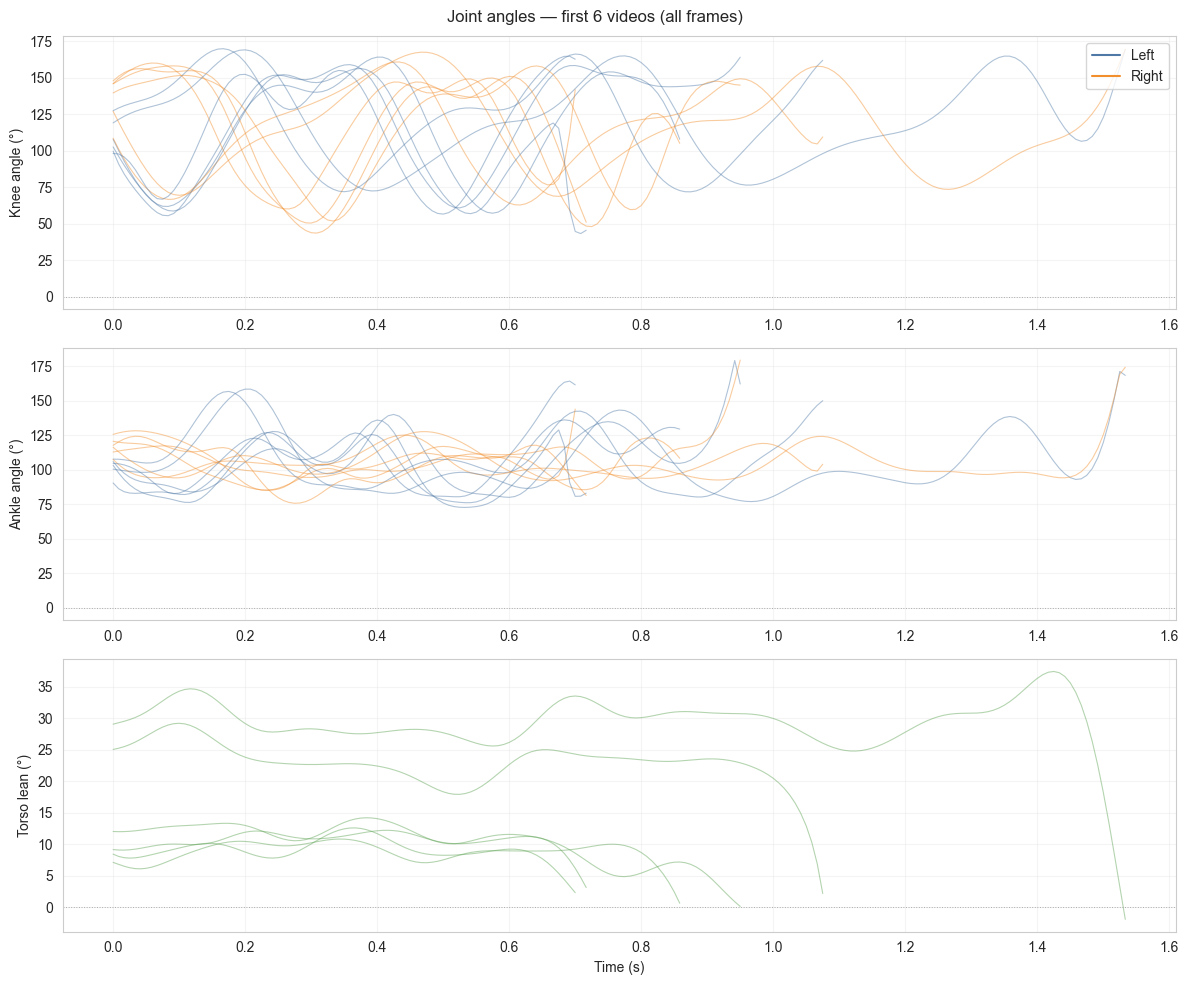

In [32]:
# Compute joint angles for a sample of records (first 6 for brevity)
SAMPLE_N = 6  # TODO: mark detected landings/takeoffs on the plots label them with the angle values; find a table with some generalized values for these metrics;

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
angle_cols = [
    (["left_knee_angle", "right_knee_angle"], "Knee angle (°)", axes[0]),
    (["left_ankle_angle", "right_ankle_angle"], "Ankle angle (°)", axes[1]),
    (["torso_lean"], "Torso lean (°)", axes[2]),
]
side_colors = {"left": "#4e79a7", "right": "#f28e2b", "torso": "#59a14f"}

for rec, pose_df in pairs[:SAMPLE_N]:
    angles = compute_joint_angles(pose_df)
    t = np.arange(len(angles)) / cfg.fps  # seconds

    for cols, ylabel, ax in angle_cols:
        for col in cols:
            side = col.split("_")[0] if "_" in col else "torso"
            ax.plot(
                t,
                angles[col],
                alpha=0.45,
                linewidth=0.8,
                color=side_colors.get(side, "#aaa"),
                label=f"{rec.athlete} {col}" if rec == pairs[0][0] else None,
            )

for cols, ylabel, ax in angle_cols:
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="#aaa", linewidth=0.7, linestyle=":")
    ax.grid(alpha=0.2)

axes[2].set_xlabel("Time (s)")
# Manual legend for sides
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=side_colors["left"], label="Left"),
    Line2D([0], [0], color=side_colors["right"], label="Right"),
]
axes[0].legend(handles=legend_elements, loc="upper right")
plt.suptitle(f"Joint angles — first {SAMPLE_N} videos (all frames)")
plt.tight_layout()
plt.show()

---
## Per-step distributions

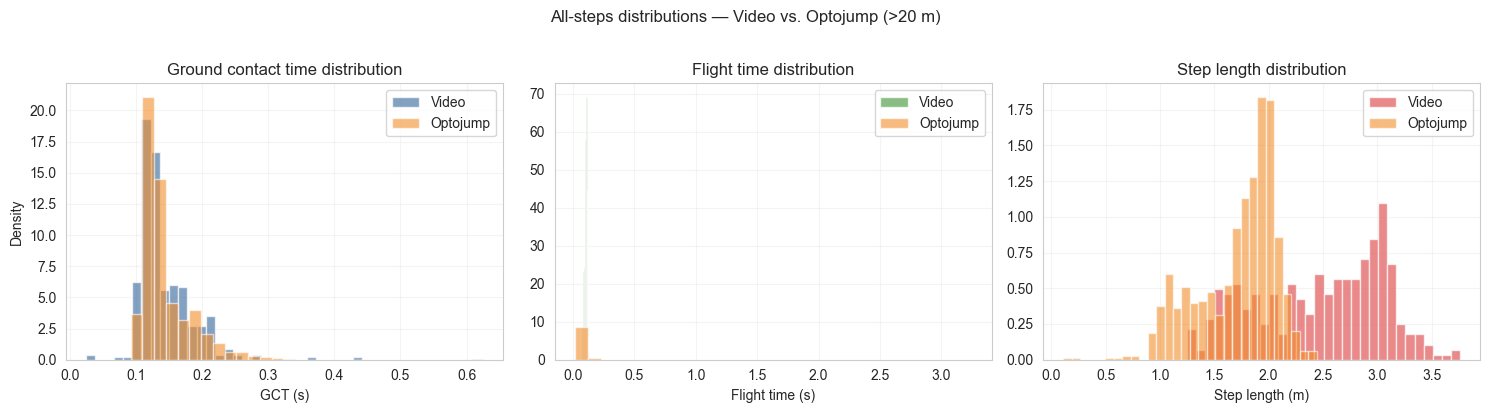

All-step means:
  GCT        — Video: 0.1421 s   Optojump: 0.1442 s
  Flight     — Video: 0.0995 s   Optojump: 0.1058 s
  Step len   — Video: 2.4694 m   Optojump: 1.7200 m


In [33]:
contact_df = pd.DataFrame(contact_all)
flight_df = pd.DataFrame(flight_all)
step_len_df = pd.DataFrame(step_len_all)

oj_steps_post20 = oj_post20.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# GCT
ax = axes[0]
if len(contact_df):
    ax.hist(
        contact_df["contact_s"],
        bins=30,
        alpha=0.7,
        color="#4e79a7",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["contact_time"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("GCT (s)")
ax.set_ylabel("Density")
ax.set_title("Ground contact time distribution")
ax.legend()
ax.grid(alpha=0.2)

# Flight time
ax = axes[1]
if len(flight_df):
    ax.hist(
        flight_df["flight_s"],
        bins=30,
        alpha=0.7,
        color="#59a14f",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["flight_time"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("Flight time (s)")
ax.set_title("Flight time distribution")
ax.legend()
ax.grid(alpha=0.2)

# Step length
ax = axes[2]
if len(step_len_df):
    ax.hist(
        step_len_df["step_length_m"].dropna(),
        bins=30,
        alpha=0.7,
        color="#e15759",
        label="Video",
        density=True,
    )
ax.hist(
    oj_steps_post20["step_length_m"].dropna(),
    bins=30,
    alpha=0.6,
    color="#f28e2b",
    label="Optojump",
    density=True,
)
ax.set_xlabel("Step length (m)")
ax.set_title("Step length distribution")
ax.legend()
ax.grid(alpha=0.2)

plt.suptitle("All-steps distributions — Video vs. Optojump (>20 m)", y=1.02)
plt.tight_layout()
plt.show()

# Print means
print("All-step means:")
if len(contact_df):
    print(
        f"  GCT        — Video: {contact_df['contact_s'].mean():.4f} s   "
        f"Optojump: {oj_steps_post20['contact_time'].mean():.4f} s"
    )
if len(flight_df):
    print(
        f"  Flight     — Video: {flight_df['flight_s'].mean():.4f} s   "
        f"Optojump: {oj_steps_post20['flight_time'].mean():.4f} s"
    )
if len(step_len_df):
    print(
        f"  Step len   — Video: {step_len_df['step_length_m'].mean():.4f} m   "
        f"Optojump: {oj_steps_post20['step_length_m'].mean():.4f} m"
    )